Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn version: 1.6.1
First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber 

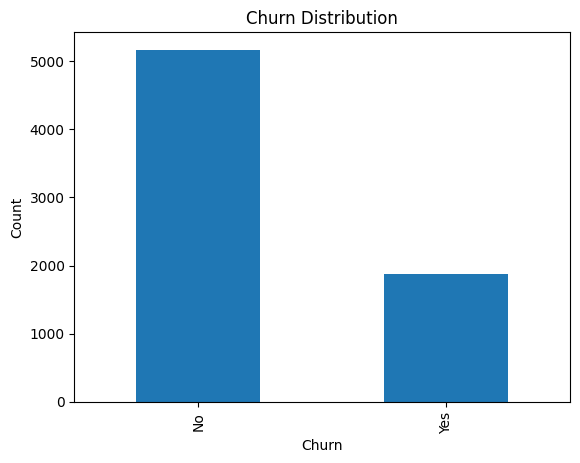


After cleaning:
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   
1              

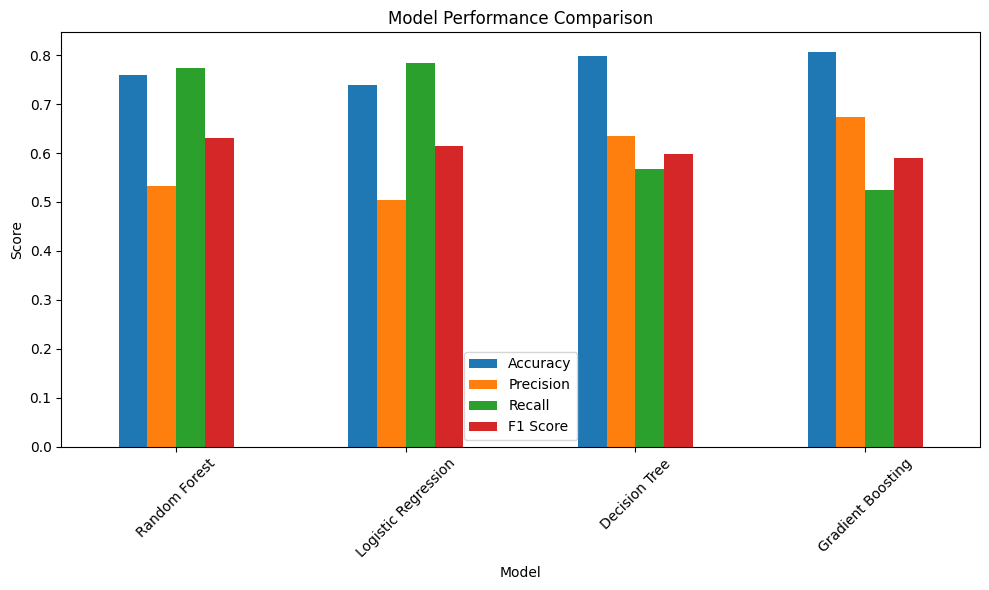

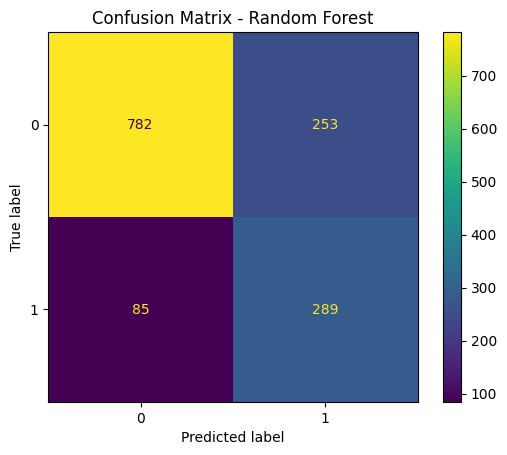


Best Model: Random Forest

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409


Best Parameters: {'model__max_depth': 8, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV F1 Score: 0.6382721018867932

Tuned Model Performance:
Accuracy: 0.7601135557132718
Precision: 0.533210332103321
Recall: 0.7727272727272727
F1 Score: 0.631004366812227


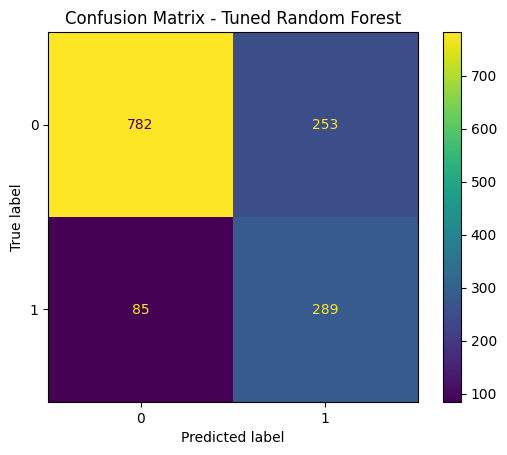


Model saved successfully.


In [2]:
# ================================
# 1. IMPORT LIBRARIES
# ===============================

import sklearn
import sys

print("Python version:", sys.version)
print("scikit-learn version:", sklearn.__version__)
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

# ================================
# 2. LOAD DATASET
# ================================
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("First 5 rows:")
print(df.head())

# ================================
# 3. INITIAL EXPLORATION
# ================================
print("\nShape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

# ================================
# 4. TARGET DISTRIBUTION
# ================================
print("\nChurn Distribution:")
print(df["Churn"].value_counts())

df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

# ================================
# 5. DATA CLEANING
# ================================
df = df.drop(columns=["customerID"])

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Convert target variable
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("\nAfter cleaning:")
print(df.head())

# ================================
# 6. FEATURE / TARGET SPLIT
# ================================
X = df.drop("Churn", axis=1)
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("\nNumerical columns:", numerical_cols)

# ================================
# 7. TRAIN-TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# 8. PREPROCESSING PIPELINE
# ================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# ================================
# 9. DEFINE MODELS
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=8,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# ================================
# 10. TRAIN & EVALUATE MODELS
# ================================
results = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })

    trained_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print("\nModel Comparison:")
print(results_df)

# ================================
# 11. PLOT MODEL COMPARISON
# ================================
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================
# 12. CONFUSION MATRIX (BEST MODEL)
# ================================
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_model_name]

y_pred_best = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print("\nBest Model:", best_model_name)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

# ================================
# 13. HYPERPARAMETER TUNING
# ================================
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 8, 12],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

# ================================
# 14. EVALUATE TUNED MODEL
# ================================
best_tuned_model = grid_search.best_estimator_

y_pred_tuned = best_tuned_model.predict(X_test)

print("\nTuned Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

# ================================
# 15. SAVE FINAL MODEL
# ================================
final_model = best_tuned_model

joblib.dump(final_model, "best_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("\nModel saved successfully.")